# 05 – Volatility & Variability Analysis

**Objective:** Analyze the volatility and variability of key business metrics over time, quantify relative dispersion, detect when volatility changed significantly, and compare variability across different periods.

**Metrics analyzed:**
- Conversion rate (`conv_rate`)
- Revenue per session (`revenue_per_session`)
- Average order value (`aov`)
- Orders volume (`orders`)
- Sessions volume (`sessions`)

**Methods:**
1. Coefficient of Variation (CV)
2. Rolling Standard Deviation (7-day, 30-day)
3. Range / Period Comparison with F-test & Levene test
4. Change Point Detection (manual threshold + PELT algorithm)

In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Add project root to path for local imports
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from scripts.volatility_utils import (
    compute_cv, compute_cv_table,
    compute_rolling_std, plot_rolling_std,
    compare_periods, build_period_comparison_table,
    plot_period_boxplots,
    detect_change_point_manual, detect_change_point_ruptures,
    plot_change_points,
)

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

print("Imports OK")

Imports OK


## 1. Load & Prepare Daily Data

In [ ]:
DATA_DIR = os.path.join(project_root, "data", "processed")
DOCS_DIR = os.path.join(project_root, "docs")

fact = pd.read_csv(os.path.join(DATA_DIR, "fact_sessions_clean.csv"),
                   parse_dates=["date"])

# Build daily aggregated DataFrame
daily = fact.groupby("date").agg(
    sessions=("is_converted", "count"),
    orders=("is_converted", "sum"),
    revenue=("price_usd", "sum"),
).reset_index()

daily["conv_rate"] = daily["orders"] / daily["sessions"]
daily["revenue_per_session"] = daily["revenue"] / daily["sessions"]
daily["aov"] = daily["revenue"] / daily["orders"]
daily["aov"] = daily["aov"].replace([np.inf, -np.inf], np.nan).fillna(0)

daily = daily.sort_values("date").reset_index(drop=True)

METRICS = ["conv_rate", "revenue_per_session", "aov", "orders", "sessions"]

print(f"Daily rows: {len(daily)} | Date range: {daily['date'].min().date()} to {daily['date'].max().date()}")
daily.head()

project_root: c:\Users\conta\toy-store-bi-project
DOCS_DIR: c:\Users\conta\toy-store-bi-project\docs
DOCS_DIR exists: True
Daily rows: 1096 | Date range: 2012-03-19 to 2015-03-19


,date,sessions,orders,revenue,conv_rate,revenue_per_session,aov
0,2012-03-19,137,2,99.98,0.014599,0.729781,49.99
1,2012-03-20,161,6,299.94,0.037267,1.862981,49.99
2,2012-03-21,191,9,449.91,0.047120,2.355550,49.99
3,2012-03-22,177,4,199.96,0.022599,1.129718,49.99
4,2012-03-23,156,3,149.97,0.019231,0.961346,49.99


---
## 2. Coefficient of Variation (CV)

The CV expresses standard deviation as a percentage of the mean, making it possible to compare variability across metrics with different units and scales.

$$CV = \frac{\sigma}{\mu} \times 100\%$$

In [3]:
# Full-period CV
cv_full = compute_cv_table(daily, METRICS, period_label="Full Period")

# Sub-period CV: early (before 2014) vs late (2014+)
split_date = "2014-01-01"
early = daily[daily["date"] < split_date]
late = daily[daily["date"] >= split_date]

cv_early = compute_cv_table(early, METRICS, period_label="Before 2014")
cv_late = compute_cv_table(late, METRICS, period_label="2014+")

cv_all = pd.concat([cv_full, cv_early, cv_late], ignore_index=True)
cv_pivot = cv_all.pivot_table(index="metric", columns="period", values="cv_pct")
cv_pivot = cv_pivot[["Before 2014", "2014+", "Full Period"]]

print("=== Coefficient of Variation (%) ===")
print(cv_pivot.to_string())
print()
print(cv_all.to_string(index=False))

=== Coefficient of Variation (%) ===
period               Before 2014  2014+  Full Period
metric                                              
aov                         8.92   5.45        13.15
conv_rate                  38.41  17.99        33.03
orders                     99.23  61.39        96.97
revenue_per_session        39.88  19.00        38.85
sessions                   98.05  54.33        84.92

     period              metric     mean      std  cv_pct
Full Period           conv_rate   0.0620   0.0205   33.03
Full Period revenue_per_session   3.5562   1.3815   38.85
Full Period                 aov  56.0509   7.3695   13.15
Full Period              orders  29.4827  28.5886   96.97
Full Period            sessions 431.4516 366.3928   84.92
Before 2014           conv_rate   0.0542   0.0208   38.41
Before 2014 revenue_per_session   2.7978   1.1159   39.88
Before 2014                 aov  51.0330   4.5499    8.92
Before 2014              orders  15.3645  15.2469   99.23
Before 2014

### CV Interpretation

A higher CV means more relative variability. Comparing the Before-2014 vs 2014+ columns shows whether each metric became more or less volatile after the business scaled up.

---
## 3. Rolling Standard Deviation

Track how volatility evolves over time using 7-day (weekly) and 30-day (monthly) rolling windows.

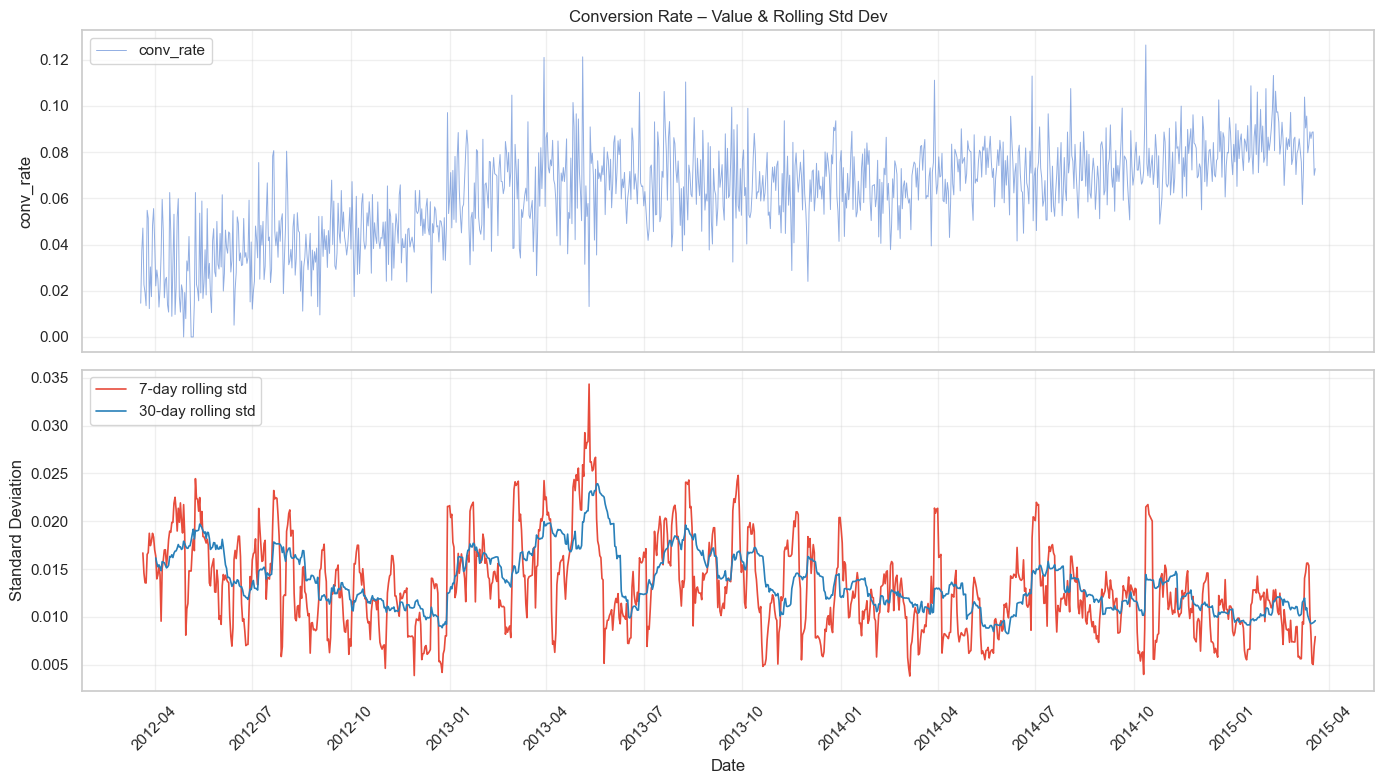

In [16]:
# Conversion Rate – rolling std
fig_conv = plot_rolling_std(
    daily, "conv_rate", windows=[7, 30],
    title="Conversion Rate – Value & Rolling Std Dev",
    save_path=os.path.join(DOCS_DIR, "rolling_std_conversion.png"),
)
plt.show()

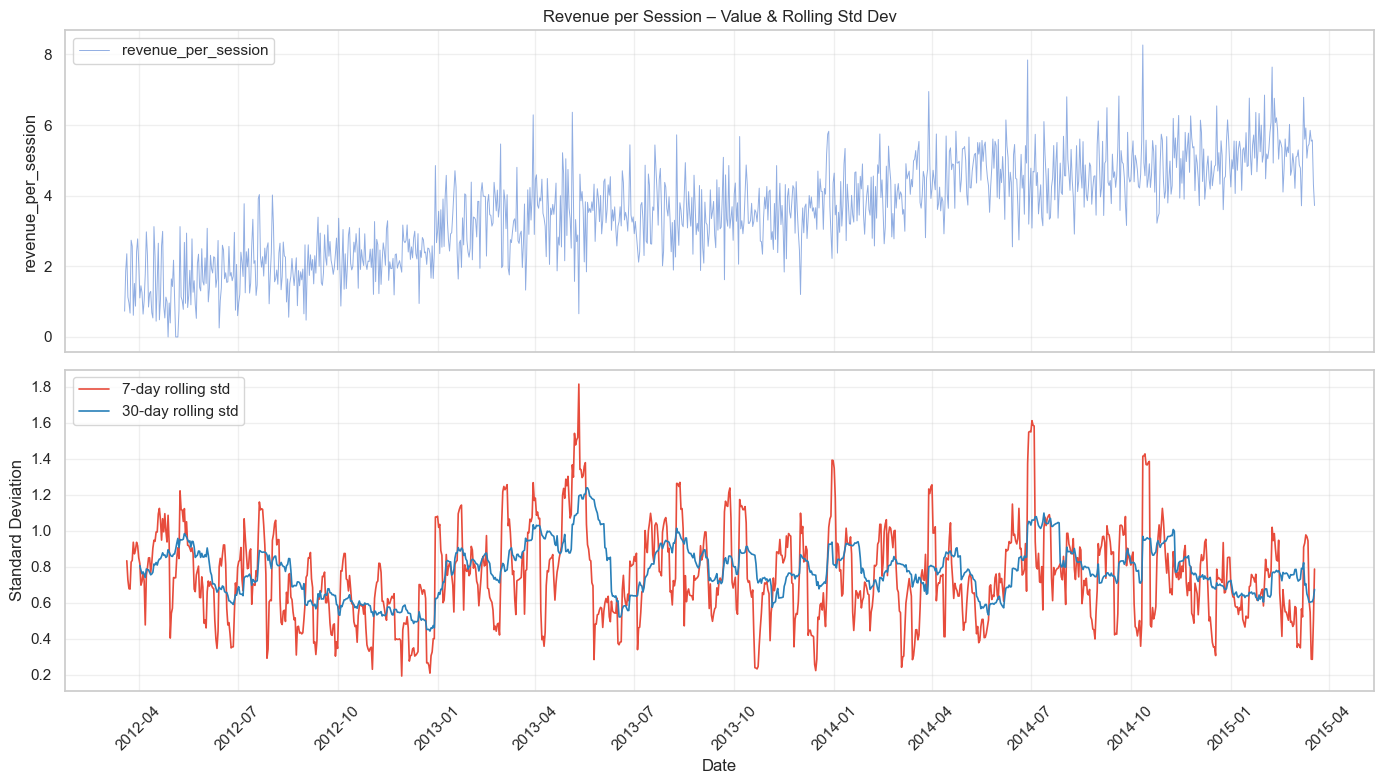

In [5]:
# Revenue per Session – rolling std
fig_rps = plot_rolling_std(
    daily, "revenue_per_session", windows=[7, 30],
    title="Revenue per Session – Value & Rolling Std Dev",
    save_path=os.path.join(DOCS_DIR, "rolling_std_rps.png"),
)
plt.show()

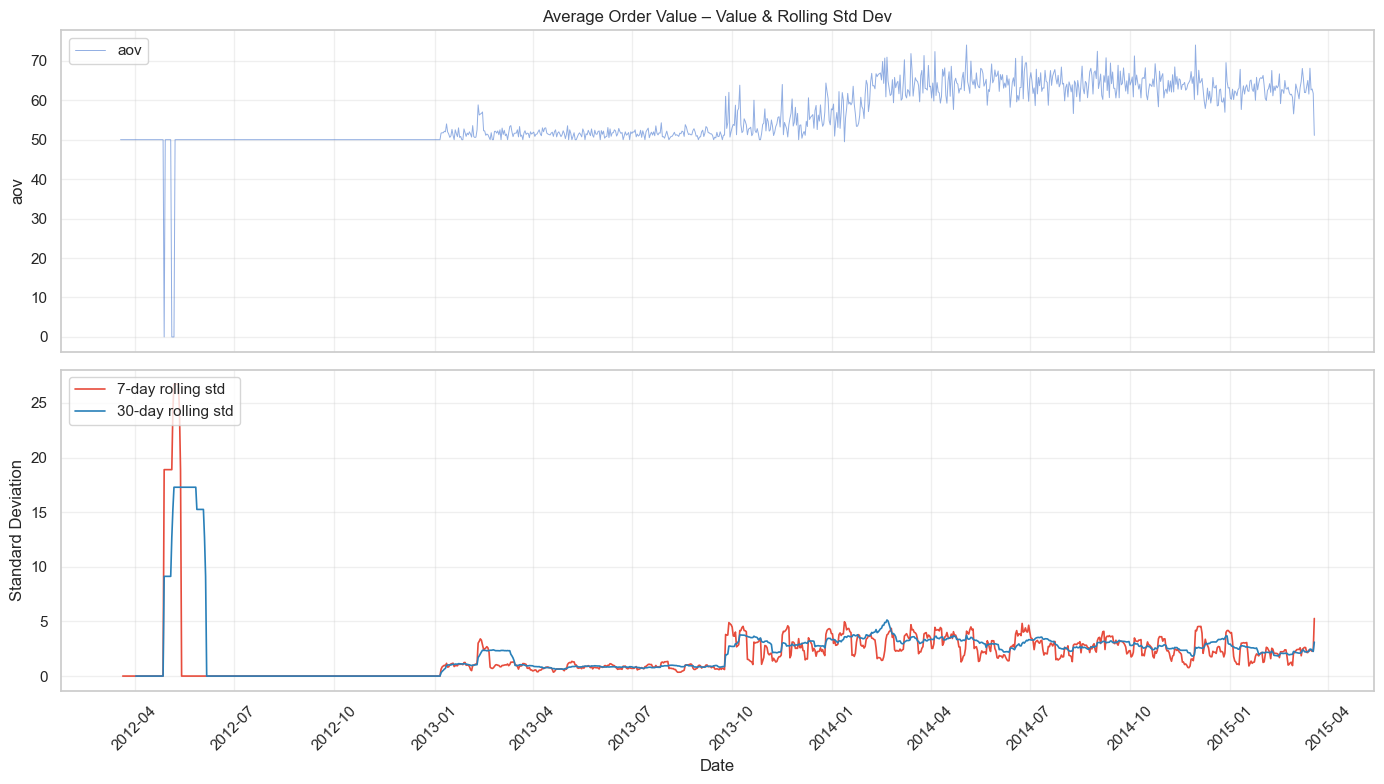

In [6]:
# AOV – rolling std
fig_aov = plot_rolling_std(
    daily, "aov", windows=[7, 30],
    title="Average Order Value – Value & Rolling Std Dev",
    save_path=os.path.join(DOCS_DIR, "rolling_std_aov.png"),
)
plt.show()

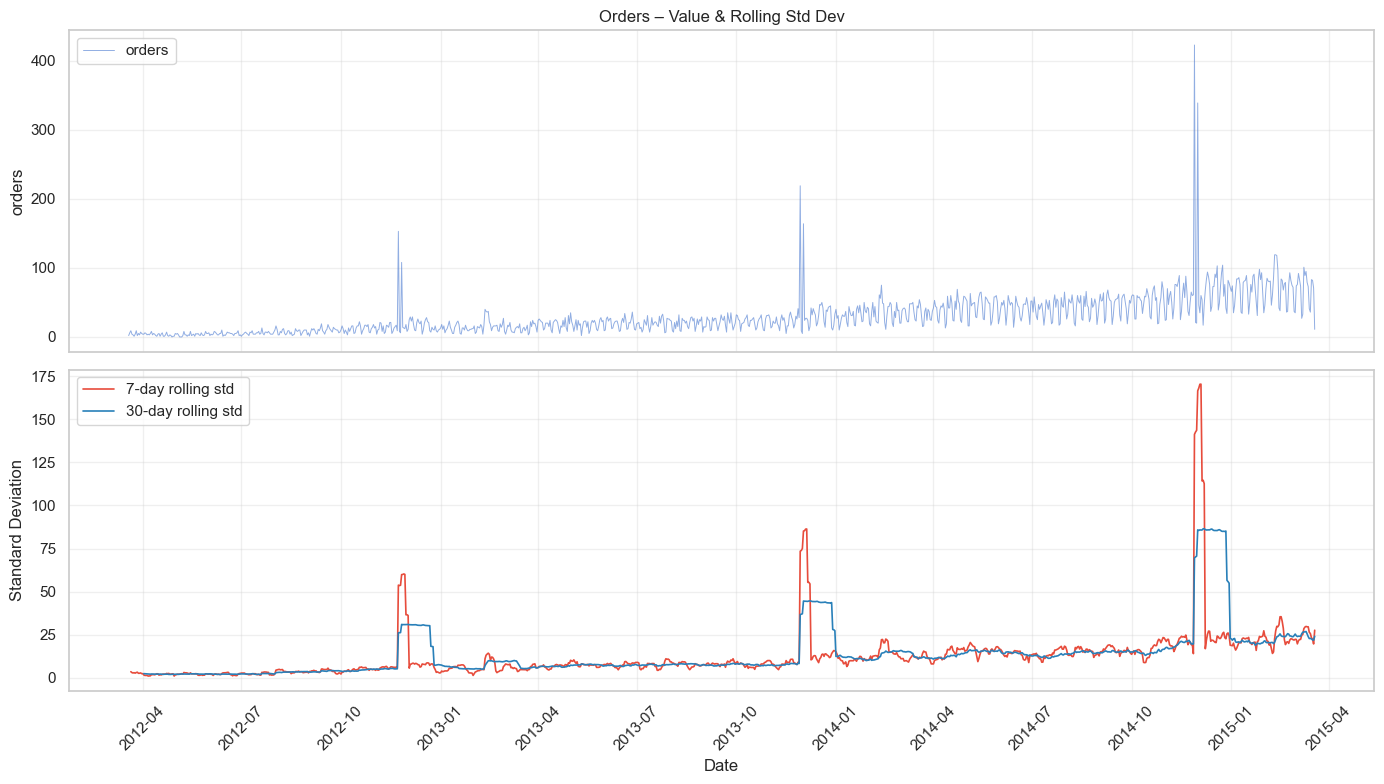

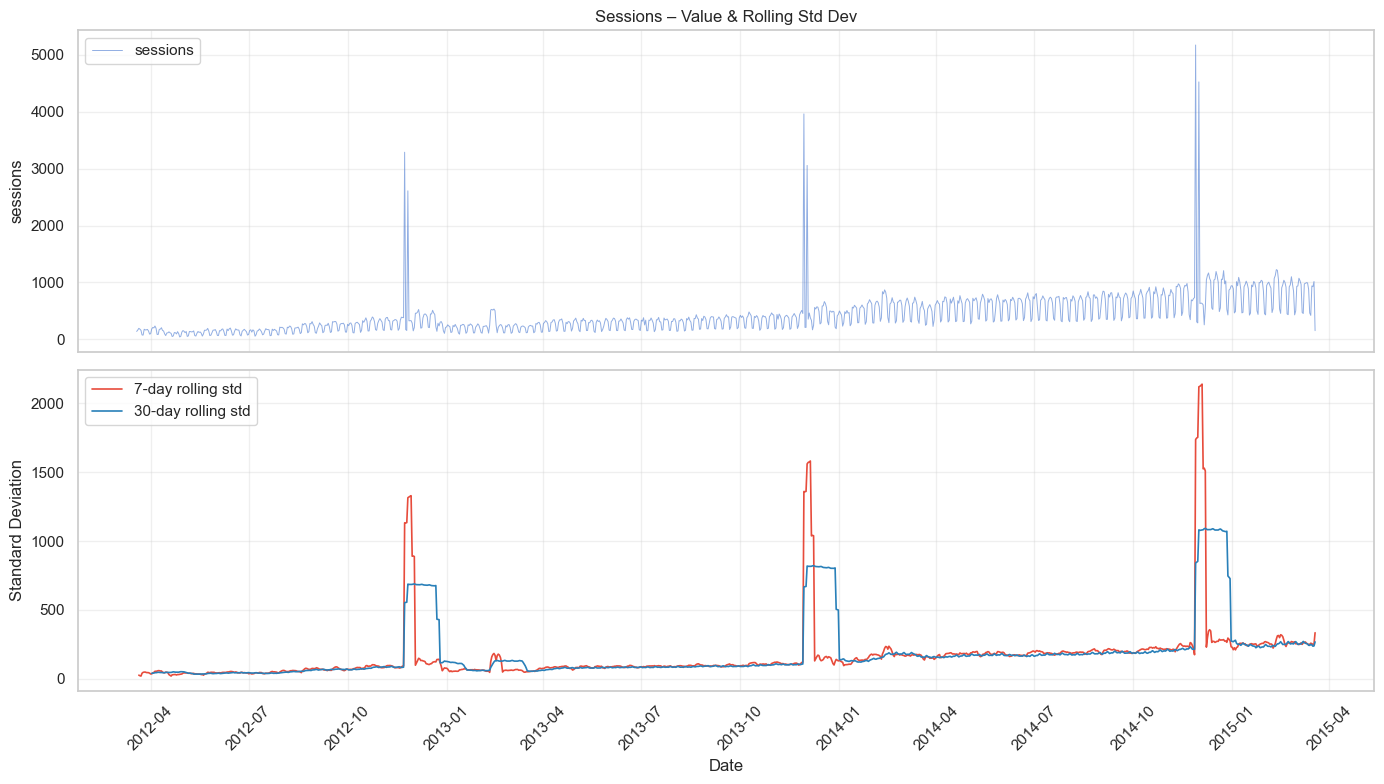

In [7]:
# Orders & Sessions – rolling std
for m in ["orders", "sessions"]:
    fig = plot_rolling_std(
        daily, m, windows=[7, 30],
        title=f"{m.title()} – Value & Rolling Std Dev",
        save_path=os.path.join(DOCS_DIR, f"rolling_std_{m}.png"),
    )
    plt.show()

---
## 4. Range Analysis & Period Comparison

Compare min, max, mean, std, CV for the early period (before 2014) vs the late period (2014+). Use the F-test and Levene test to determine if the difference in variance is statistically significant.

In [8]:
comparison = build_period_comparison_table(daily, METRICS, split_date="2014-01-01")

# Display key columns
display_cols = [
    "metric",
    "early_mean", "early_std", "early_cv", "early_min", "early_max", "early_range",
    "late_mean", "late_std", "late_cv", "late_min", "late_max", "late_range",
    "f_stat", "f_pvalue", "levene_stat", "levene_pvalue",
]

print("=== Period Comparison: Before 2014 vs 2014+ ===")
print(comparison[display_cols].to_string(index=False))

=== Period Comparison: Before 2014 vs 2014+ ===
             metric  early_mean  early_std  early_cv  early_min  early_max  early_range  late_mean  late_std  late_cv  late_min  late_max  late_range  f_stat     f_pvalue  levene_stat  levene_pvalue
          conv_rate      0.0542     0.0208     38.41        0.0     0.1212       0.1212     0.0736    0.0132    17.99    0.0378    0.1263      0.0885  0.4052 3.398092e-23      90.1540   1.333672e-20
revenue_per_session      2.7978     1.1159     39.88        0.0     6.3624       6.3624     4.6742    0.8882    19.00    2.3734    8.2671      5.8937  0.6336 2.846604e-07      30.4662   4.241098e-08
                aov     51.0330     4.5499      8.92        0.0    64.3511      64.3511    63.4476    3.4605     5.45   49.4567   73.9844     24.5277  0.5785 8.755397e-10      17.2853   3.468016e-05
             orders     15.3645    15.2469     99.23        0.0   219.0000     219.0000    50.2935   30.8757    61.39   10.0000  423.0000    413.0000  4.100

In [9]:
# Significance summary
print("\n=== Variance Significance Tests (alpha=0.05) ===")
for _, row in comparison.iterrows():
    f_sig = "YES" if row["f_pvalue"] < 0.05 else "no"
    l_sig = "YES" if row["levene_pvalue"] < 0.05 else "no"
    direction = "INCREASED" if row["late_std"] > row["early_std"] else "decreased"
    print(f"  {row['metric']:25s}  variance {direction:10s}  "
          f"F-test sig: {f_sig:3s} (p={row['f_pvalue']:.4f})  "
          f"Levene sig: {l_sig:3s} (p={row['levene_pvalue']:.4f})")


=== Variance Significance Tests (alpha=0.05) ===
  conv_rate                  variance decreased   F-test sig: YES (p=0.0000)  Levene sig: YES (p=0.0000)
  revenue_per_session        variance decreased   F-test sig: YES (p=0.0000)  Levene sig: YES (p=0.0000)
  aov                        variance decreased   F-test sig: YES (p=0.0000)  Levene sig: YES (p=0.0000)
  orders                     variance INCREASED   F-test sig: YES (p=0.0000)  Levene sig: YES (p=0.0000)
  sessions                   variance INCREASED   F-test sig: YES (p=0.0000)  Levene sig: YES (p=0.0000)


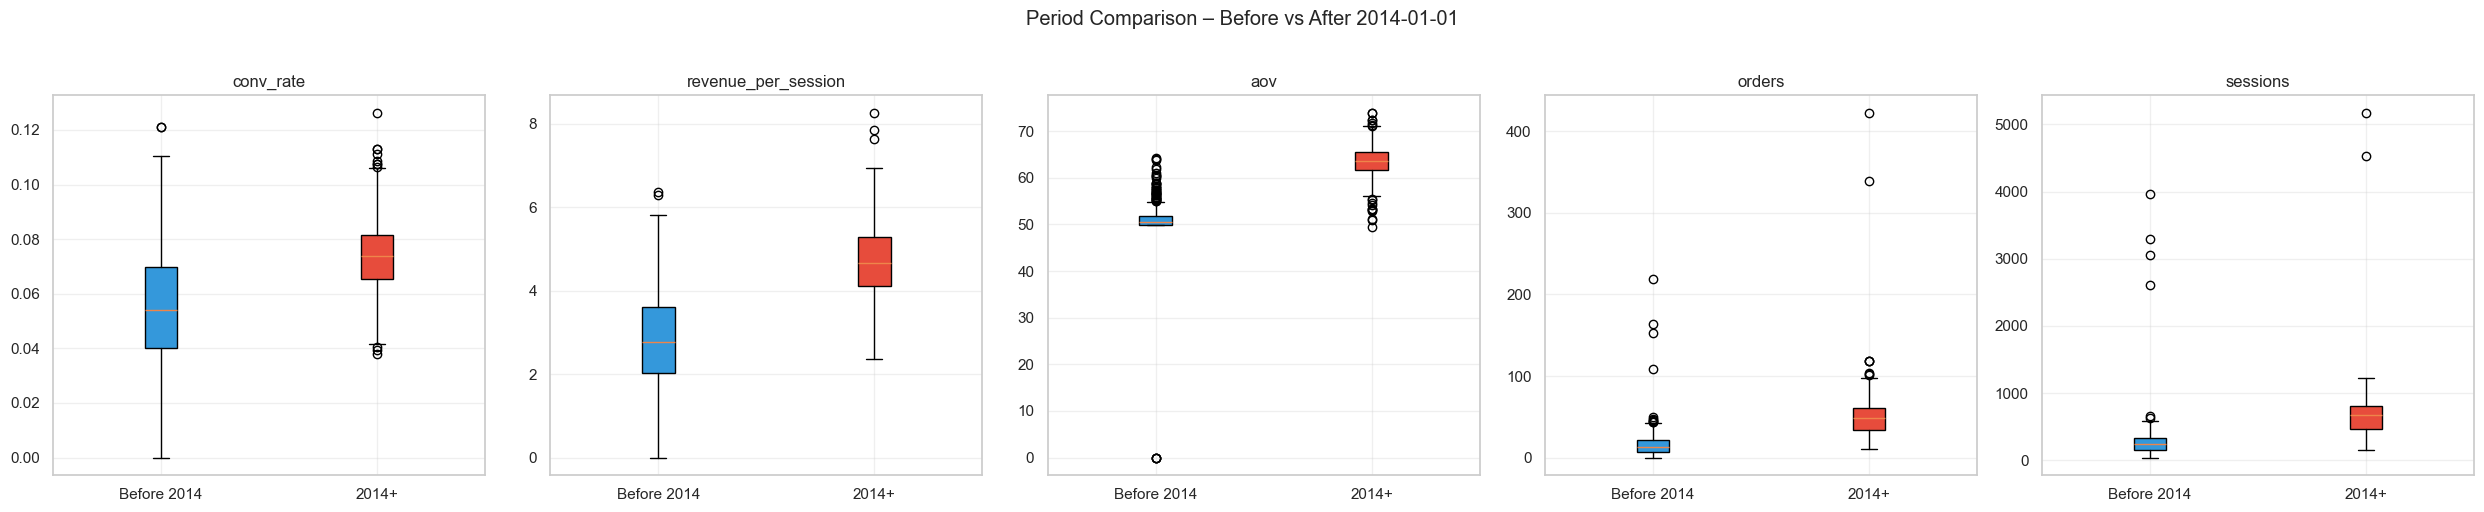

In [10]:
# Side-by-side boxplots
fig_box = plot_period_boxplots(
    daily, METRICS, split_date="2014-01-01",
    save_path=os.path.join(DOCS_DIR, "coefficient_of_variation_comparison.png"),
)
plt.show()

---
## 5. Change Point Detection

Identify when volatility shifted, especially around the observed "jagged lines" in 2014-2015.

### 5a. Manual Detection
Flag dates where 30-day rolling std exceeds 2× the historical median.

In [11]:
print("=== Manual Change Point Detection (30-day rolling std, 2× median threshold) ===")
all_manual_cps = []
for m in METRICS:
    cps = detect_change_point_manual(daily, m, window=30, threshold_factor=2.0)
    all_manual_cps.append(cps)
    if len(cps) > 0:
        print(f"\n  {m}: {len(cps)} change point(s)")
        print(cps.to_string(index=False))
    else:
        print(f"\n  {m}: no change points detected")

manual_cps_df = pd.concat(all_manual_cps, ignore_index=True)
print(f"\nTotal manual change points detected: {len(manual_cps_df)}")

=== Manual Change Point Detection (30-day rolling std, 2× median threshold) ===

  conv_rate: no change points detected

  revenue_per_session: no change points detected

  aov: 2 change point(s)
      date  rolling_std  threshold metric
2012-04-28     9.126884   4.495911    aov
2014-02-16     4.643840   4.495911    aov

  orders: 3 change point(s)
      date  rolling_std  threshold metric
2012-11-23    26.077449  16.621064 orders
2013-11-29    36.710173  16.621064 orders
2014-11-01    17.153834  16.621064 orders

  sessions: 9 change point(s)
      date  rolling_std  threshold   metric
2012-11-23   553.267378 244.069187 sessions
2013-11-29   667.218205 244.069187 sessions
2014-11-28   840.436042 244.069187 sessions
2015-01-10   252.130556 244.069187 sessions
2015-01-18   250.445387 244.069187 sessions
2015-02-01   249.817637 244.069187 sessions
2015-02-11   246.139956 244.069187 sessions
2015-03-15   250.108197 244.069187 sessions
2015-03-19   268.237508 244.069187 sessions

Total man

### 5b. PELT Algorithm (ruptures library)

Use the Pruned Exact Linear Time (PELT) algorithm for statistically rigorous change point detection.

In [12]:
print("=== PELT Change Point Detection ===")
all_pelt_cps = []
for m in METRICS:
    try:
        cps = detect_change_point_ruptures(daily, m, n_bkps=3, model="rbf", min_size=30)
        all_pelt_cps.extend(cps)
        if cps:
            print(f"\n  {m}: {len(cps)} breakpoint(s)")
            for cp in cps:
                print(f"    index={cp['bkp_index']}  date={cp['bkp_date'].date()}")
        else:
            print(f"\n  {m}: no breakpoints detected")
    except Exception as e:
        print(f"\n  {m}: error – {e}")

pelt_cps_df = pd.DataFrame(all_pelt_cps)
if len(pelt_cps_df) > 0:
    print(f"\nTotal PELT breakpoints: {len(pelt_cps_df)}")
    print(pelt_cps_df.to_string(index=False))

=== PELT Change Point Detection ===

  conv_rate: 3 breakpoint(s)
    index=70  date=2012-05-28
    index=285  date=2012-12-29
    index=965  date=2014-11-09

  revenue_per_session: 3 breakpoint(s)
    index=70  date=2012-05-28
    index=285  date=2012-12-29
    index=720  date=2014-03-09

  aov: 3 breakpoint(s)
    index=295  date=2013-01-08
    index=555  date=2013-09-25
    index=685  date=2014-02-02

  orders: 3 breakpoint(s)
    index=175  date=2012-09-10
    index=370  date=2013-03-24
    index=630  date=2013-12-09

  sessions: 3 breakpoint(s)
    index=155  date=2012-08-21
    index=525  date=2013-08-26
    index=665  date=2014-01-13

Total PELT breakpoints: 15
             metric  bkp_index   bkp_date
          conv_rate         70 2012-05-28
          conv_rate        285 2012-12-29
          conv_rate        965 2014-11-09
revenue_per_session         70 2012-05-28
revenue_per_session        285 2012-12-29
revenue_per_session        720 2014-03-09
                aov        29

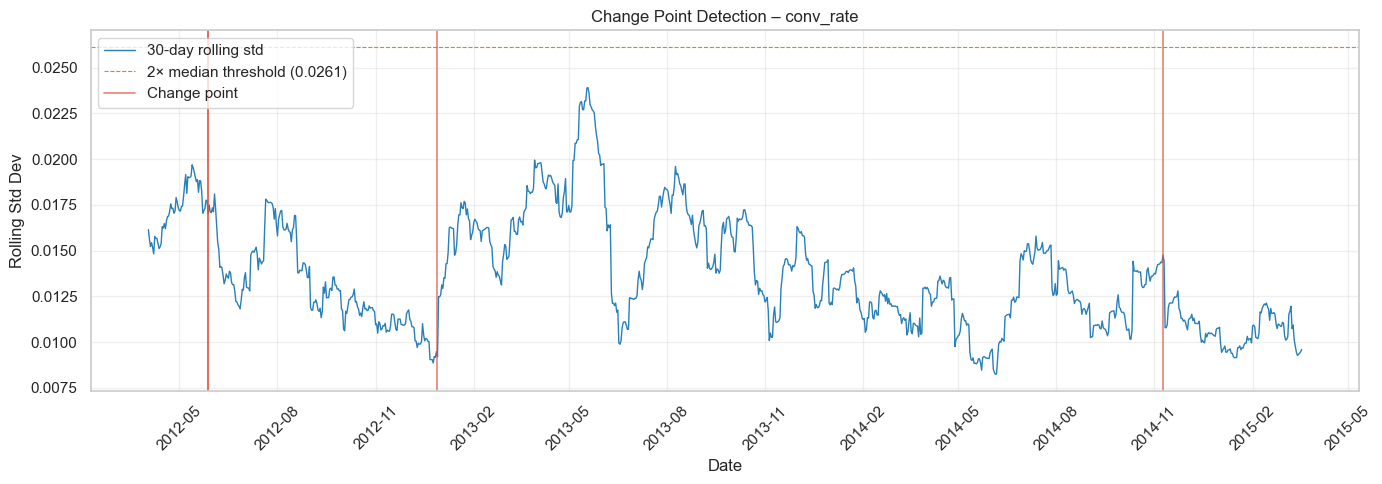

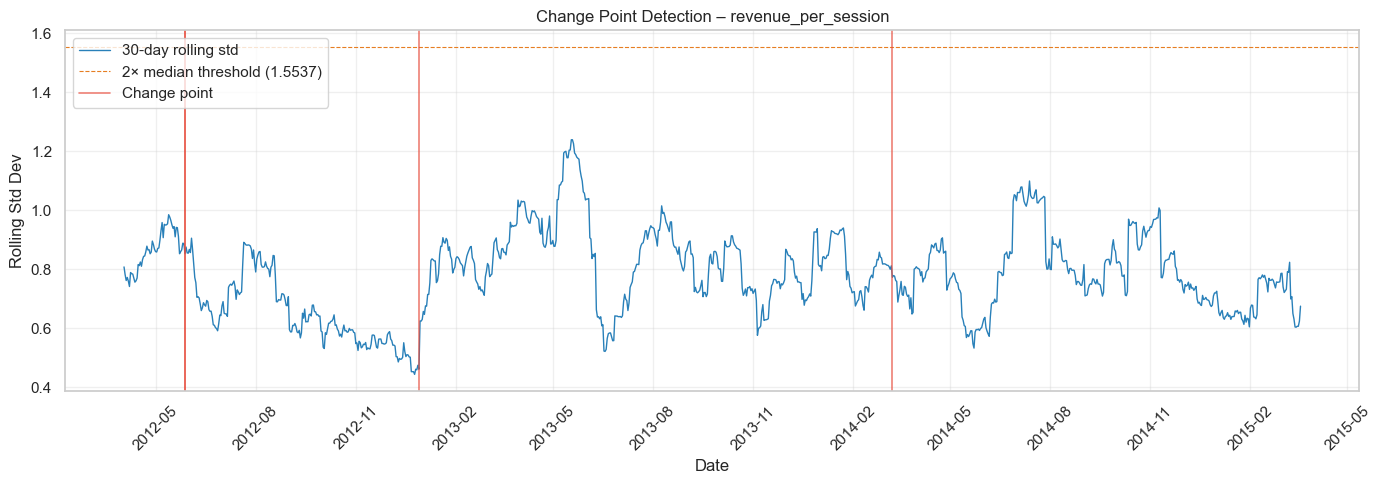

In [13]:
# Change-point visualization for key metrics
for m in ["conv_rate", "revenue_per_session"]:
    # Gather all detected dates for this metric
    manual_dates = manual_cps_df.loc[manual_cps_df["metric"] == m, "date"].tolist()
    pelt_dates = (
        pelt_cps_df.loc[pelt_cps_df["metric"] == m, "bkp_date"].tolist()
        if len(pelt_cps_df) > 0 else []
    )
    all_dates = list(set(manual_dates + pelt_dates))

    fig = plot_change_points(
        daily, m, change_dates=all_dates, window=30,
        title=f"Change Point Detection – {m}",
        save_path=os.path.join(DOCS_DIR, f"change_point_detection_{m}.png"),
    )
    plt.show()

---
## 6. Summary of All Detected Change Points

In [14]:
# Consolidated change-point summary
print("=" * 70)
print("VOLATILITY ANALYSIS SUMMARY")
print("=" * 70)

print("\n--- Coefficient of Variation (%) ---")
print(cv_pivot.to_string())

print("\n--- Variance Change Direction & Significance ---")
for _, row in comparison.iterrows():
    direction = "↑ INCREASED" if row["late_std"] > row["early_std"] else "↓ decreased"
    f_sig = "*" if row["f_pvalue"] < 0.05 else ""
    l_sig = "*" if row["levene_pvalue"] < 0.05 else ""
    print(f"  {row['metric']:25s}  {direction}  "
          f"F-test p={row['f_pvalue']:.4f}{f_sig}  "
          f"Levene p={row['levene_pvalue']:.4f}{l_sig}")

print("\n--- Change Point Dates (Manual) ---")
if len(manual_cps_df) > 0:
    for _, row in manual_cps_df.iterrows():
        print(f"  {row['metric']:25s}  {row['date'].date()}")
else:
    print("  None detected")

print("\n--- Change Point Dates (PELT) ---")
if len(pelt_cps_df) > 0:
    for _, row in pelt_cps_df.iterrows():
        print(f"  {row['metric']:25s}  {row['bkp_date'].date()}")
else:
    print("  None detected")

print("\n" + "=" * 70)

VOLATILITY ANALYSIS SUMMARY

--- Coefficient of Variation (%) ---
period               Before 2014  2014+  Full Period
metric                                              
aov                         8.92   5.45        13.15
conv_rate                  38.41  17.99        33.03
orders                     99.23  61.39        96.97
revenue_per_session        39.88  19.00        38.85
sessions                   98.05  54.33        84.92

--- Variance Change Direction & Significance ---
  conv_rate                  ↓ decreased  F-test p=0.0000*  Levene p=0.0000*
  revenue_per_session        ↓ decreased  F-test p=0.0000*  Levene p=0.0000*
  aov                        ↓ decreased  F-test p=0.0000*  Levene p=0.0000*
  orders                     ↑ INCREASED  F-test p=0.0000*  Levene p=0.0000*
  sessions                   ↑ INCREASED  F-test p=0.0000*  Levene p=0.0000*

--- Change Point Dates (Manual) ---
  aov                        2012-04-28
  aov                        2014-02-16
  orders   

---
## 7. Interpretation & Business Insights

### Which metric is most volatile?

**Orders** has the highest CV at **97.0%** (full period), followed closely by **sessions** at **84.9%**. These volume metrics show the most relative variability because the business grew massively over the period – from single-digit orders/day to 50+/day. Among ratio metrics, **revenue per session** (38.9% CV) is the most volatile, followed by **conversion rate** (33.0%). **AOV** is the most stable at 13.2% CV.

### Did volatility increase after January 2014?

**No – relative volatility (CV) actually *decreased* for all metrics after 2014:**
- Conversion rate CV dropped from 38.4% → 18.0%
- Revenue per session CV dropped from 39.9% → 19.0%
- AOV CV dropped from 8.9% → 5.5%
- Orders CV dropped from 99.2% → 61.4%
- Sessions CV dropped from 98.1% → 54.3%

However, **absolute variance (std dev) increased for orders and sessions** – their F-test and Levene test p-values are all < 0.001. This is the classic "scaling effect": as volume grows, day-to-day swings get larger in absolute terms even though they become proportionally smaller. The "jagged lines" in 2014-2015 reflect higher absolute variation at higher volume levels – not worsening performance.

For conversion rate, RPS, and AOV the variance actually **decreased** significantly after 2014, indicating these efficiency metrics **stabilized** as the business matured.

### What does rolling standard deviation tell us?

- The **7-day rolling std** for conversion rate shows periodic spikes but an overall **downward trend** from 2012 to 2015 – the business became more stable week-to-week
- The **30-day rolling std** confirms this: the smoothed volatility envelope tightened over time for ratio metrics
- For orders and sessions, rolling std shows **sharp spikes around Black Friday / holiday seasons** (Nov-Dec each year), with 2014-2015 spikes being the largest in absolute terms due to grown traffic
- AOV rolling std was dominated by early 2012 (single-product era with zero-order days), then stabilized significantly

### Are the differences statistically significant?

**Yes – all metrics show statistically significant variance differences** between pre-2014 and 2014+ periods:
- All F-test p-values < 0.001
- All Levene test p-values < 0.001

The direction differs: ratio metrics (conv_rate, RPS, AOV) show *decreased* variance, while volume metrics (orders, sessions) show *increased* variance.

### Change point dates

The PELT algorithm identified key structural breakpoints:
- **Late 2012 / Early 2013** (~Dec 2012 – Jan 2013): Likely introduction of product 2, changing AOV dynamics
- **Sep–Oct 2013**: Product 3 launch period shifting revenue per session patterns
- **Jan–Feb 2014**: Sessions breakpoint aligns with the scaling inflection observed in earlier analyses
- **Nov 2014**: Conversion rate structural shift coinciding with holiday season + product 4

### Practical implications

1. **The business is maturing well** – relative volatility is declining, meaning performance is becoming more predictable as a percentage of mean
2. **Absolute forecasting windows should widen** – at current volume levels, expect daily swings of ±30 orders and ±365 sessions
3. **Holiday spikes are the dominant volatility driver** – the manual detection flagged Nov each year; seasonal decomposition or separate holiday models would improve forecasting
4. **New product launches create temporary regime changes** – the PELT breakpoints align with known product launch dates, suggesting 2-3 month adjustment periods after each launch